### Pandas - Time Series


#### Kinds of Date and Time Data

+ Time Stamps reference a particular moment in time (July 4th, 2015 at 7:00am)

+ Time interval and periods reference a length of time between a beginning and end point

+ Time deltas or durations reference an exact length of time (duration of 22.56 seconds)

#### Native Python dates and times: datetime and dateutil

In [2]:
## Manually build a date using the datetime type
from datetime import datetime
datetime(year=2021, month=1, day=16)

datetime.datetime(2021, 1, 16, 0, 0)

In [3]:
## dateutil module lets you parse dates from a variety of sting formats
from dateutil import parser
date = parser.parse("16th of January, 2021")
date

datetime.datetime(2021, 1, 16, 0, 0)

In [4]:
## with a datetime object you can print days of the week
date.strftime('%A')

'Saturday'

%A is one of the stanard string format codes for print dates.

More information at https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior

More information on dateutil at http://labix.org/python-dateutil

Similar to list of Python numerical variables are suboptimal compared to NumPy-style typed numerical arrays,
list of Python datetime objects are suboptimal compared to encoded dates.

The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly. 
The date time64 requires a very specific input format.

In [5]:
import numpy as np

In [8]:
## datetime64 dtype encodes dates as 64-bit integers allows arrays of dates to be represented very compactly
## datetime64 requires a very specific input format
date = np.array('2015-07-04', dtype=np.datetime64)
date

array('2015-07-04', dtype='datetime64[D]')

In [9]:
## Once date is formatted, able to do vectorized operations on it
date + np.arange(12)

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

+ datetime64 and timedelta64 objects is that they are built on a fundamental time unit.


+ Because the datetime64 object is limited to 64-bit precision, the range of encodable times
 is 2^64 times this fundamental unit


+ datetime64 imposes a trade-off between time resolution and maximum time span

In [13]:
## numpy infers desired unit from input
np.datetime64('2021-01-18') # day|

numpy.datetime64('2021-01-18')

In [14]:
np.datetime64('2021-01-18 12:00') # minute

numpy.datetime64('2021-01-18T12:00')

In [15]:
## Force any desired fundamental unit
np.datetime64('2021-01-18 12:59:59.50', 'ns') # nanosecond

numpy.datetime64('2021-01-18T12:59:59.500000000')

NumPy's datetime64 notation has the codes for date and time codes
https://numpy.org/doc/stable/reference/arrays.datetime.html


Pandas builds on all of the previously discussed tools to provide a Timestamp object.

Timestamp object combines the ease of use of datetime and dateutil with the efficiency of numpy.datetime64.

From a group of Timestamp objects, Pandas can construct a DatetimeIndex.

In [17]:
## Repeat previous example with Pandas
import pandas as pd
date = pd.to_datetime("18th of January, 2021")
date

Timestamp('2021-01-18 00:00:00')

In [18]:
date.strftime('%A')

'Monday'

In [19]:
## NumPy-style vectorized operations
date + pd.to_timedelta(np.arange(12), 'D')

DatetimeIndex(['2021-01-18', '2021-01-19', '2021-01-20', '2021-01-21',
               '2021-01-22', '2021-01-23', '2021-01-24', '2021-01-25',
               '2021-01-26', '2021-01-27', '2021-01-28', '2021-01-29'],
              dtype='datetime64[ns]', freq=None)

#### Pandas Time Series: Indexing by Time

Pandas time series tools really become useful is when you begin to index data by timestamps.

In [21]:
## construct a Series object that has timeindexed data
index = pd.DatetimeIndex(['2021-01-18', '2021-01-19', '2021-01-20', '2021-01-21'])
data = pd.Series([0, 1, 2, 3], index=index)
data

2021-01-18    0
2021-01-19    1
2021-01-20    2
2021-01-21    3
dtype: int64

In [22]:
## Can use Series indexing patterns
data['2021-1-20':'2021-1-21']

2021-01-20    2
2021-01-21    3
dtype: int64

In [23]:
## There are special date-only indexing operations, like passing a year to get all data from the year
data['2021']

2021-01-18    0
2021-01-19    1
2021-01-20    2
2021-01-21    3
dtype: int64

### Pandas Time Series Data Structures

+ For time stamps, Pandas provides the Timestamp type. The associated index structure is DatetimeIndex.

+ For time periods, Pandas provides the Period type. The associated index structure is PeriodIndex.

+ For time deltas or durations, Pandas provides the Timedelta type. The associated index structure is TimedeltaIndex.

In [24]:
## Passing a single date to pd.to_datetime() yields a Timestamp; passing a series of dates by default yields a DatetimeIndex
dates = pd.to_datetime([datetime(2015, 7, 3), '4th of July, 2015', '2015-Jul-6', '07-07-2015', '20150708'])
dates

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-06', '2015-07-07',
               '2015-07-08'],
              dtype='datetime64[ns]', freq=None)

In [25]:
## DatetimeIndex can be converted to a PeriodIndex with the to_period() function with the addition of a frequency code
dates.to_period('D')

PeriodIndex(['2015-07-03', '2015-07-04', '2015-07-06', '2015-07-07',
             '2015-07-08'],
            dtype='period[D]', freq='D')

In [26]:
## A TimedeltaIndex is created, for example, when one date is subtracted from another
dates - dates[0]

TimedeltaIndex(['0 days', '1 days', '3 days', '4 days', '5 days'], dtype='timedelta64[ns]', freq=None)

In [27]:
## Creation of regular date sequences
## pd.date_range() for timestamps, pd.period_range() for periods, and pd.timedelta_range() for time deltas
## pd.date_range(start, stop, frequency code)
pd.date_range('2021-01-18', '2021-01-31')

DatetimeIndex(['2021-01-18', '2021-01-19', '2021-01-20', '2021-01-21',
               '2021-01-22', '2021-01-23', '2021-01-24', '2021-01-25',
               '2021-01-26', '2021-01-27', '2021-01-28', '2021-01-29',
               '2021-01-30', '2021-01-31'],
              dtype='datetime64[ns]', freq='D')

In [28]:
## Start point and a number of periods
pd.date_range('2021-01-18', periods=8)

DatetimeIndex(['2021-01-18', '2021-01-19', '2021-01-20', '2021-01-21',
               '2021-01-22', '2021-01-23', '2021-01-24', '2021-01-25'],
              dtype='datetime64[ns]', freq='D')

In [30]:
## Modify the spacing by altering the freq arguement (defaults to D)
pd.date_range('2021-01-18', periods=8, freq='H')

DatetimeIndex(['2021-01-18 00:00:00', '2021-01-18 01:00:00',
               '2021-01-18 02:00:00', '2021-01-18 03:00:00',
               '2021-01-18 04:00:00', '2021-01-18 05:00:00',
               '2021-01-18 06:00:00', '2021-01-18 07:00:00'],
              dtype='datetime64[ns]', freq='H')

In [31]:
## Regular sequence of period values
pd.period_range('2021-01', periods=8, freq='M')

PeriodIndex(['2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06',
             '2021-07', '2021-08'],
            dtype='period[M]', freq='M')

In [32]:
## Regular sequence of durations increasing by an hour
pd.timedelta_range(0, periods=10, freq='H')

TimedeltaIndex(['00:00:00', '01:00:00', '02:00:00', '03:00:00', '04:00:00',
                '05:00:00', '06:00:00', '07:00:00', '08:00:00', '09:00:00'],
               dtype='timedelta64[ns]', freq='H')

For more information on the use of frequencies or offsets, see https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html

### Resampling, Shifting, and Windowing

In [37]:
## pandas-datareader knows how to import financial data from various sources
## load Google's closing price history
from pandas_datareader import data

goog = data.DataReader('GOOG', start='2004', end='2021', data_source='yahoo')
goog.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2004-08-19,51.835709,47.800831,49.813290,49.982655,44871361.0,49.982655
2004-08-20,54.336334,50.062355,50.316402,53.952770,22942874.0,53.952770
2004-08-23,56.528118,54.321388,55.168217,54.495735,18342897.0,54.495735
2004-08-24,55.591629,51.591621,55.412300,52.239197,15319808.0,52.239197
2004-08-25,53.798351,51.746044,52.284027,52.802086,9232276.0,52.802086


In [38]:
## For simplicity, use just closing price
goog = goog['Close']

In [39]:
## Visualize using plot method
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()

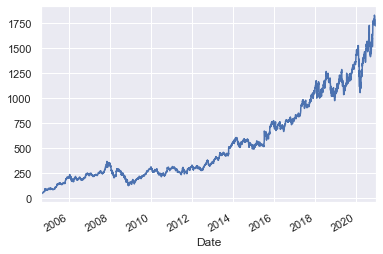

In [40]:
goog.plot();

Resampling time series data at a higher or lower frequency.

Can be done using the resample() method or asfreq() method.

resample() is fundamentally and aggregation while asfreq() is fundamentally a data selection.

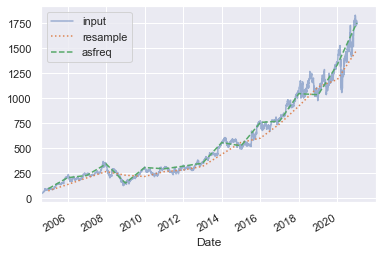

In [41]:
## At each point, resample reports the average of the previous year
## while asfreq reports that value at the end of the year
goog.plot(alpha=0.5, style='-')
goog.resample('BA').mean().plot(style=':')
goog.asfreq('BA').plot(style='--');
plt.legend(['input', 'resample', 'asfreq'],
loc='upper left');